In [9]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [43]:
class TempState(TypedDict):
    tempcel:float
    tempfer:float
    status:str

In [48]:
def labelTemp(state:TempState)->TempState:
    status = "high"
    if(state['tempfer'] > 130):
        status = "High"
        print("High")
    else :
        status = "Low"
        print('Low')
    state['status'] = status
    return state

In [49]:
def convert2Fer(state:TempState)->TempState:
    cel = state['tempcel']
    state['tempfer'] = cel*(9/5)+32
    return state

In [50]:
graph = StateGraph(TempState)

graph.add_node('convert2Fer',convert2Fer)
graph.add_node('label_Temp',labelTemp)

graph.add_edge(START,'convert2Fer')
graph.add_edge('convert2Fer','label_Temp')
graph.add_edge('label_Temp',END)

workflow = graph.compile()


In [51]:
intital_state = workflow.invoke({'tempcel':25.53})

final_state = workflow.invoke(intital_state)

print(final_state)

Low
Low
{'tempcel': 25.53, 'tempfer': 77.95400000000001, 'status': 'Low'}


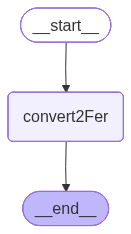

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())